# RQ2 — Scaling Distributed Spatial JoinsAnalysis of national-scale spatial join benchmarks comparingsingle-node engines (DuckDB, PostGIS) with distributed Databricksstrategies across multiple worker counts and dataset sizes.

In [1]:
from __future__ import annotations

import platform
import re
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
import yaml

from src.analysis.loading import (
    enrich_samples, extract_strategy, extract_worker_count,
    load_costs, load_experiments, load_metadata, load_samples,
)
from src.analysis.tables import (
    build_consistency_table, build_cross_pass_table,
    build_descriptive_table, build_pairwise_table, build_scaling_table,
    compact_descriptive_table, format_consistency_table,
    split_pairwise_effects, split_pairwise_significance,
)
from src.analysis.validation import run_all_validations
from src.plotting.style import StyleConfig
from src.plotting.charts import (
    plot_median_bars, plot_violin,
    plot_cpu_breakdown, plot_network_io, plot_cv_iqr,
    plot_scaling_curve, plot_databricks_metrics,
    plot_size_scaling, plot_ranking_stability,
)

In [2]:
RUN_ID = "2026-05-23-0NVQKS"
BLOB_STORAGE_ACCOUNT_NAME = "doppabs"
BENCHMARK_CONTAINER = "benchmarks"
METADATA_CONTAINER = "metadata"
BENCHMARK_METADATA_BLOB_NAME = "benchmark_metadata.parquet"
BENCHMARKS_YML_PATH = Path("../doppa/benchmarks.yml")

FIGURES_DIR = Path("figures")
TABLES_DIR = Path("tables")
FIGURES_DIR.mkdir(exist_ok=True)
TABLES_DIR.mkdir(exist_ok=True)

PRIMARY_METRICS = ["elapsed_time", "network_bytes_received", "network_bytes_sent"]
AUXILIARY_METRICS = ["cpu_time_user_seconds", "cpu_time_system_seconds"]
DATABRICKS_METRICS = [
    "executor_input_bytes_read",
    "executor_run_time_ms",
    "shuffle_read_bytes",
    "shuffle_write_bytes",
    "driver_collection_time_ms",
]

ITERATION_CEILINGS = {
    "point-in-polygon-lookup": 2500,
    "knn-search": 4000,
    "bbox-filtering": 900,
    "national-scale-spatial-join": 5,
}
WORKLOAD_TYPES = sorted(ITERATION_CEILINGS.keys(), key=len, reverse=True)

RQ2_WORKLOAD = "national-scale-spatial-join"

style = StyleConfig()
style.apply_rcparams()

## Data Loading

In [3]:
db = duckdb.connect()
db.install_extension("azure")
db.load_extension("azure")
db.execute(f"""
    CREATE OR REPLACE SECRET azure_secret(
        TYPE azure, PROVIDER config, ACCOUNT_NAME '{BLOB_STORAGE_ACCOUNT_NAME}'
    );
""")
if platform.system() == "Linux":
    db.execute("SET azure_transport_option_type = curl")

experiments = load_experiments(BENCHMARKS_YML_PATH)
samples_df = load_samples(db, BENCHMARK_CONTAINER, RUN_ID)
metadata_df = load_metadata(db, METADATA_CONTAINER, BENCHMARK_METADATA_BLOB_NAME, RUN_ID)
costs_df = load_costs(db, BENCHMARK_CONTAINER, RUN_ID)
samples_df = enrich_samples(samples_df, experiments, WORKLOAD_TYPES, ITERATION_CEILINGS)
successful_all = samples_df[samples_df["status"] == "success"].copy()

print(f"Loaded {len(samples_df)} samples, {len(successful_all)} successful")

Loaded 6065 samples, 6063 successful


## Validation

In [4]:
run_all_validations(samples_df, successful_all, metadata_df, experiments)

Schema V4 check passed
query_id                                                           benchmark_run
national-scale-spatial-join-databricks-partitioned-16-nodes-large  1                1.0
national-scale-spatial-join-databricks-partitioned-2-nodes-large   1                1.0
dtype: float64
                                             query_id  achieved_iterations  \
6   national-scale-spatial-join-databricks-broadca...                  5.0   
8   national-scale-spatial-join-databricks-default...                  5.0   
9   national-scale-spatial-join-databricks-default...                  0.0   
10  national-scale-spatial-join-databricks-default...                  0.0   
11  national-scale-spatial-join-databricks-partiti...                  0.0   
12  national-scale-spatial-join-databricks-partiti...                  0.0   

    sample_n  
6        NaN  
8        NaN  
9        NaN  
10       NaN  
11       NaN  
12       NaN  
Batch run_id consistency check complete
Result cardin

In [5]:
successful = successful_all[successful_all["workload_type"] == RQ2_WORKLOAD].copy()

print(f"RQ2 data: {len(successful)} successful iterations")
print(f"Configurations: {sorted(successful['configuration'].unique())}")
print(f"Dataset sizes: {sorted(successful['dataset_size'].unique())}")

RQ2 data: 5 successful iterations
Configurations: ['databricks-broadcast-4-nodes']
Dataset sizes: ['large']


## Statistical Analysis

In [6]:
all_metrics = PRIMARY_METRICS + AUXILIARY_METRICS
if successful["executor_input_bytes_read"].notna().any():
    all_metrics = all_metrics + DATABRICKS_METRICS

table1 = build_descriptive_table(successful, all_metrics)
print(f"Table 1 (descriptive): {len(table1)} rows")
table1.head(10)

Table 1 (descriptive): 10 rows


n  \
query_id                                           benchmark_run metric                         
national-scale-spatial-join-databricks-broadcas... 1             cpu_time_system_seconds    5   
                                                                 cpu_time_user_seconds      5   
                                                                 driver_collection_time_ms  5   
                                                                 elapsed_time               5   
                                                                 executor_input_bytes_read  5   
                                                                 executor_run_time_ms       5   
                                                                 network_bytes_received     5   
                                                                 network_bytes_sent         5   
                                                                 shuffle_read_bytes         5   
                                                                 shuffle_write_bytes        5   

                                                                                                  median  \
query_id                                           benchmark_run metric                                    
national-scale-spatial-join-databricks-broadcas... 1             cpu_time_system_seconds    1.000000e-02   
                                                                 cpu_time_user_seconds      1.500000e-01   
                                                                 driver_collection_time_ms  0.000000e+00   
                                                                 elapsed_time               2.042465e+02   
                                                                 executor_input_bytes_read  2.026654e+10   
                                                                 executor_run_time_ms       6.001262e+06   
                                                                 network_bytes_received     7.610000e+04   
                                                                 network_bytes_sent         3.942000e+04   
                                                                 shuffle_read_bytes         2.139992e+10   
                                                                 shuffle_write_bytes        2.139992e+10   

                                                                                                    mean  \
query_id                                           benchmark_run metric                                    
national-scale-spatial-join-databricks-broadcas... 1             cpu_time_system_seconds    6.000000e-03   
                                                                 cpu_time_user_seconds      1.560000e-01   
                                                                 driver_collection_time_ms  6.686000e+02   
                                                                 elapsed_time               2.046232e+02   
                                                                 executor_input_bytes_read  2.431984e+10   
                                                                 executor_run_time_ms       7.242836e+06   
                                                                 network_bytes_received     7.616380e+04   
                                                                 network_bytes_sent         3.939800e+04   
                                                                 shuffle_read_bytes         2.567990e+10   
                                                                 shuffle_write_bytes        2.567990e+10   

                                                                                                     std  \
query_id                                           benchmark_run metric                                    
national-scale-spatial-join-databricks-broadcas... 1             cpu_time_system_seconds    5.477226e-03   
         

In [7]:
table2 = build_cross_pass_table(table1)
print(f"Table 2 (cross-pass): {len(table2)} rows")
table2.head(10)

Table 2 (cross-pass): 0 rows


,,headline_median,pass_1_median,pass_2_median,pass_3_median,pass_range,pass_range_relative,consistent
query_id,metric,,,,,,,


In [8]:
table3 = build_pairwise_table(successful, PRIMARY_METRICS)
print(f"Table 3 (pairwise): {len(table3)} rows")
table3.head(10)

Table 3 (pairwise): 0 rows


""


In [9]:
table4 = build_consistency_table(table3)
if len(table4) > 0:
    fc = table4["fully_consistent"].sum()
    total = len(table4)
    print(f"Table 4 (consistency): {total} comparisons, {fc} fully consistent ({fc / total:.0%})")
table4.head(10)

""


## RQ2 — Scaling Analysis

In [10]:
rq2_data = successful.copy()
rq2_data["worker_count"] = rq2_data["configuration"].apply(extract_worker_count)
rq2_data["strategy"] = rq2_data["configuration"].apply(extract_strategy)

scaling_rows = []
for (strategy, wc, ds), group in rq2_data.groupby(["strategy", "worker_count", "dataset_size"]):
    if pd.isna(wc):
        continue
    pass_medians = []
    for br in sorted(group["benchmark_run"].unique()):
        vals = group[(group["benchmark_run"] == br)]["elapsed_time"].values
        if len(vals) > 0:
            pass_medians.append(float(np.median(vals)))
    if pass_medians:
        scaling_rows.append({
            "strategy": strategy,
            "worker_count": int(wc),
            "dataset_size": ds,
            "headline_median": float(np.median(pass_medians)),
            "pass_range": float(np.ptp(pass_medians)),
            "pass_min": float(np.min(pass_medians)),
            "pass_max": float(np.max(pass_medians)),
        })

rq2_scaling = pd.DataFrame(scaling_rows)

single_node_rows = []
sn_data = rq2_data[rq2_data["worker_count"].isna()]
for (cfg, ds), group in sn_data.groupby(["configuration", "dataset_size"]):
    pass_medians = []
    for br in sorted(group["benchmark_run"].unique()):
        vals = group[(group["benchmark_run"] == br)]["elapsed_time"].values
        if len(vals) > 0:
            pass_medians.append(float(np.median(vals)))
    if pass_medians:
        single_node_rows.append({
            "configuration": cfg,
            "dataset_size": ds,
            "headline_median": float(np.median(pass_medians)),
        })

rq2_single_node = pd.DataFrame(single_node_rows)

print("Scaling data:")
print(rq2_scaling.to_string() if len(rq2_scaling) else "(no distributed data)")
print("\nSingle-node baselines:")
print(rq2_single_node.to_string() if len(rq2_single_node) else "(none)")

Scaling data:
    strategy  worker_count dataset_size  headline_median  pass_range   pass_min   pass_max
0  broadcast             4        large        204.24648         0.0  204.24648  204.24648

Single-node baselines:
(none)


## Visualisation

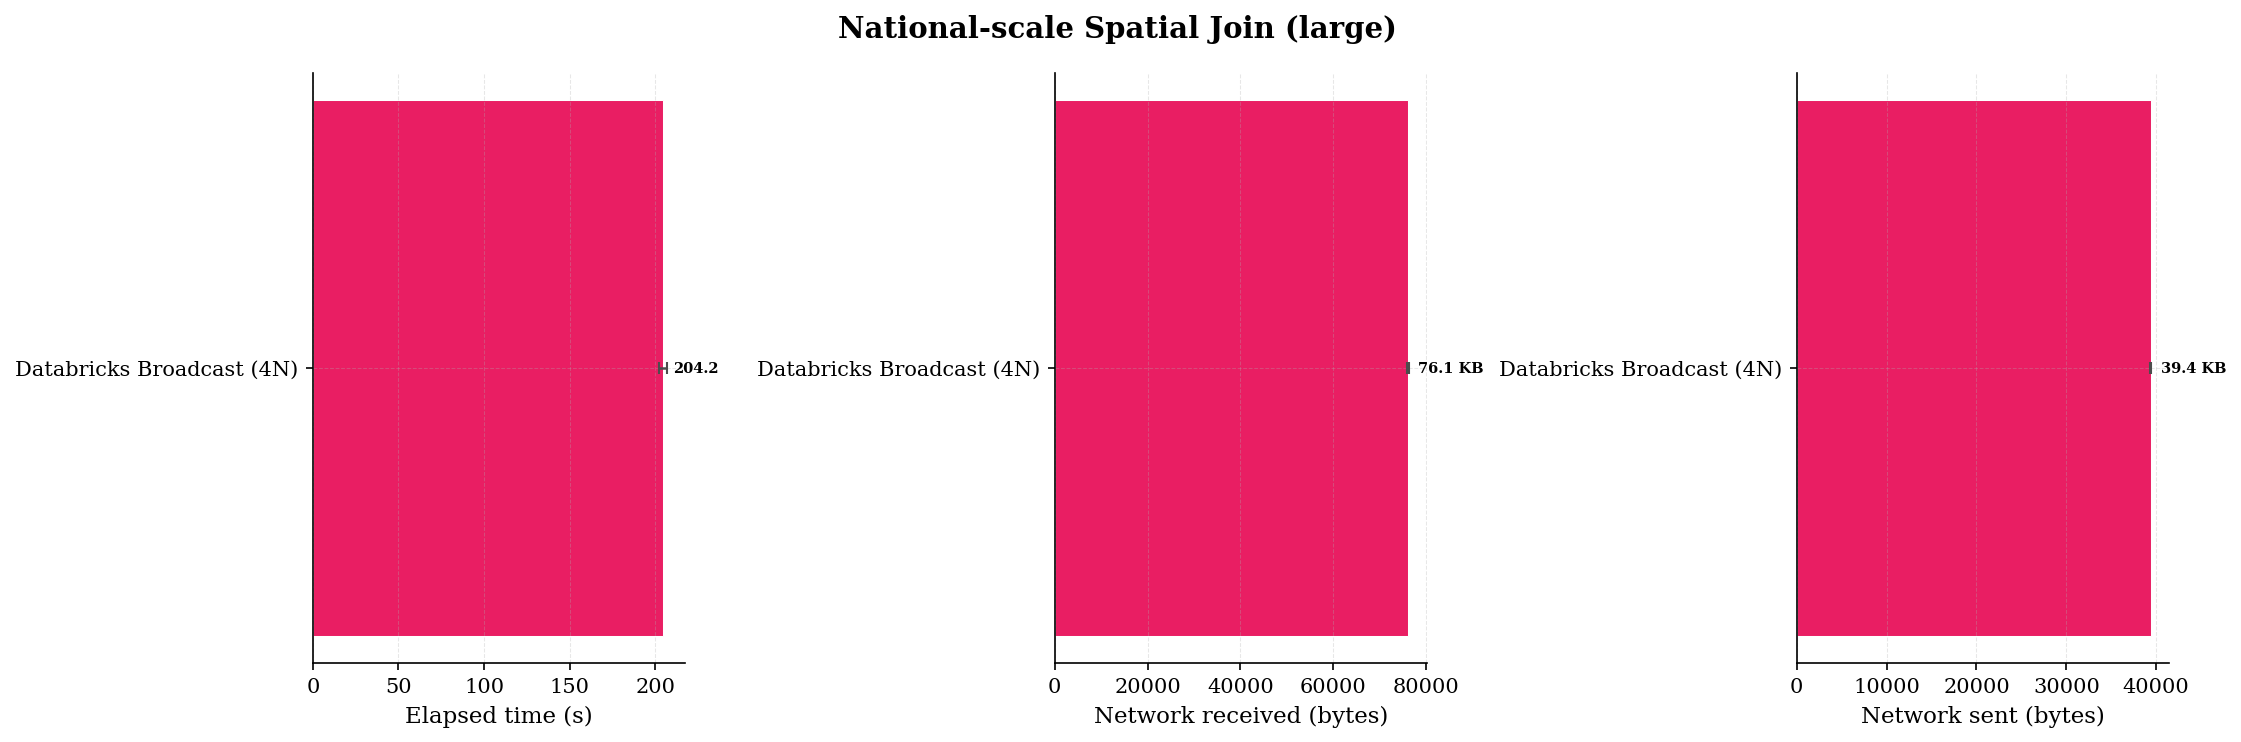

In [11]:
plot_median_bars(successful, PRIMARY_METRICS, style, FIGURES_DIR)

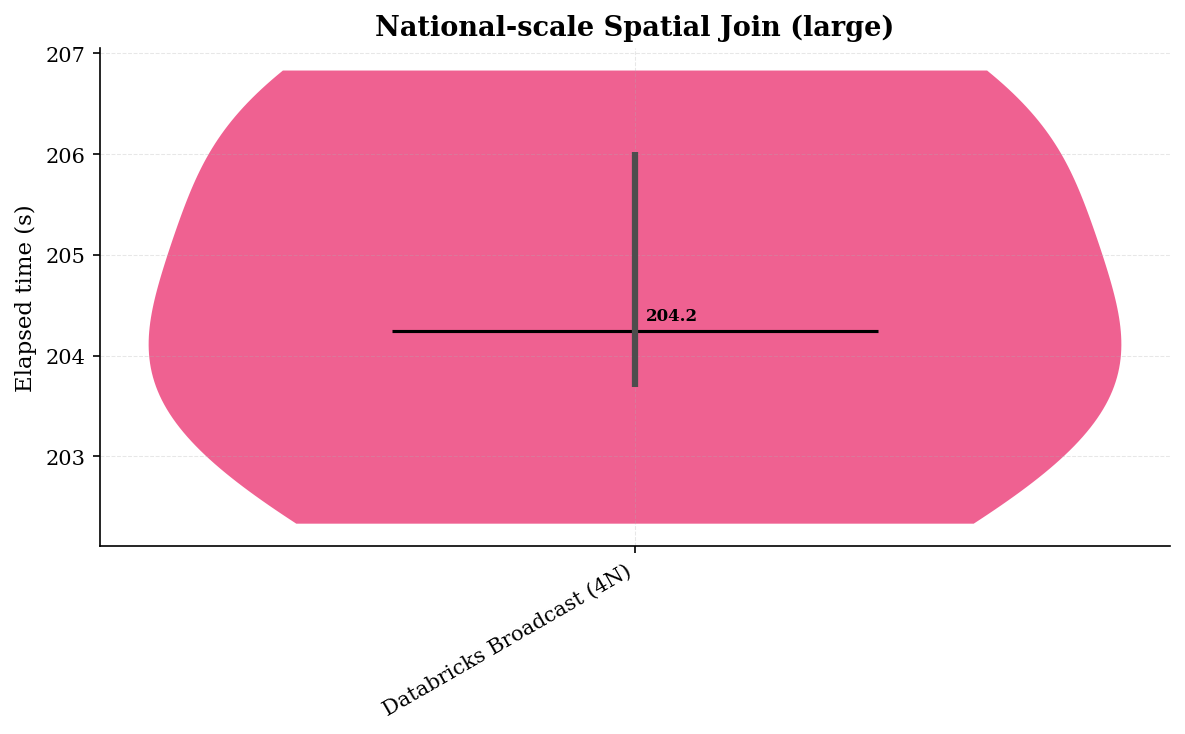

In [12]:
plot_violin(successful, style, FIGURES_DIR)

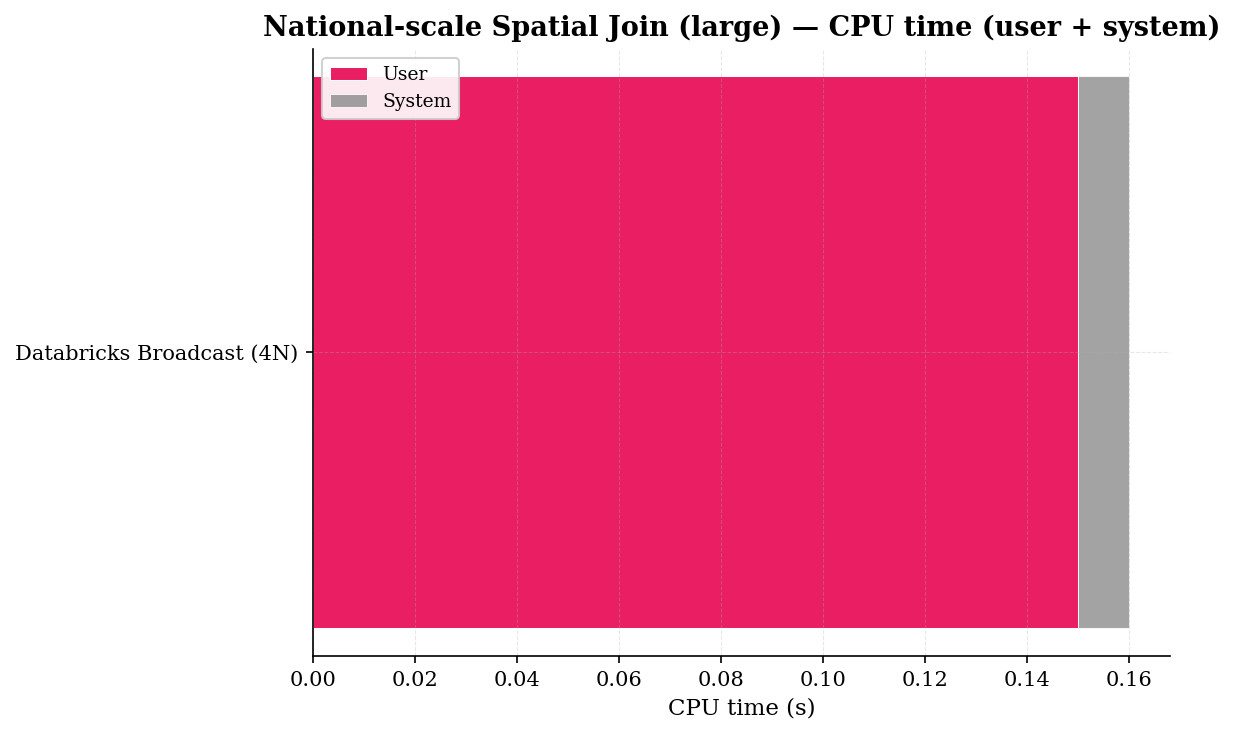

In [13]:
plot_cpu_breakdown(successful, style, FIGURES_DIR)

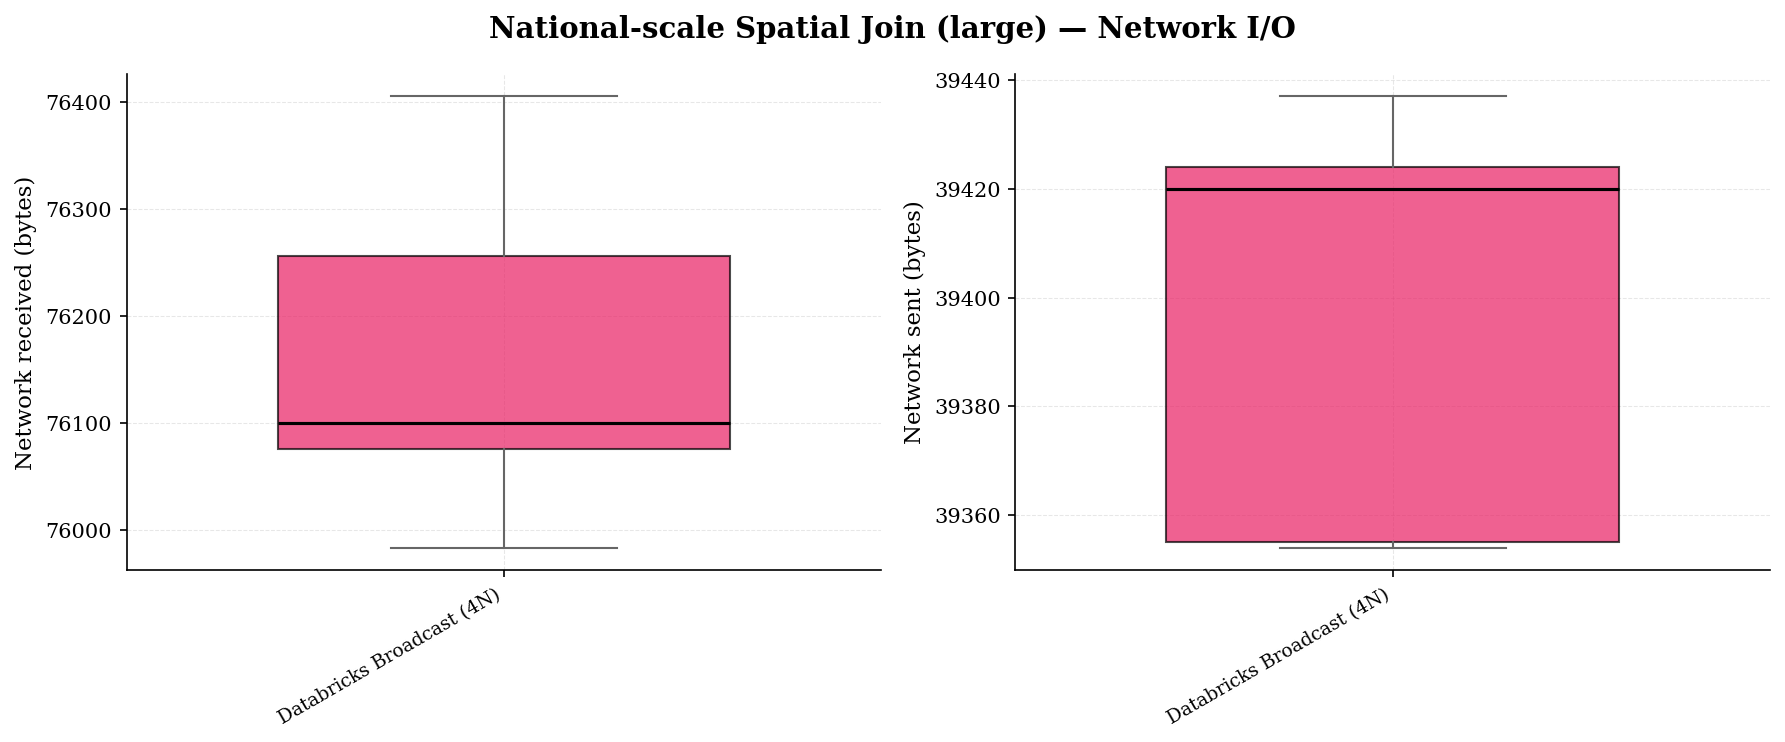

In [14]:
plot_network_io(successful, style, FIGURES_DIR)

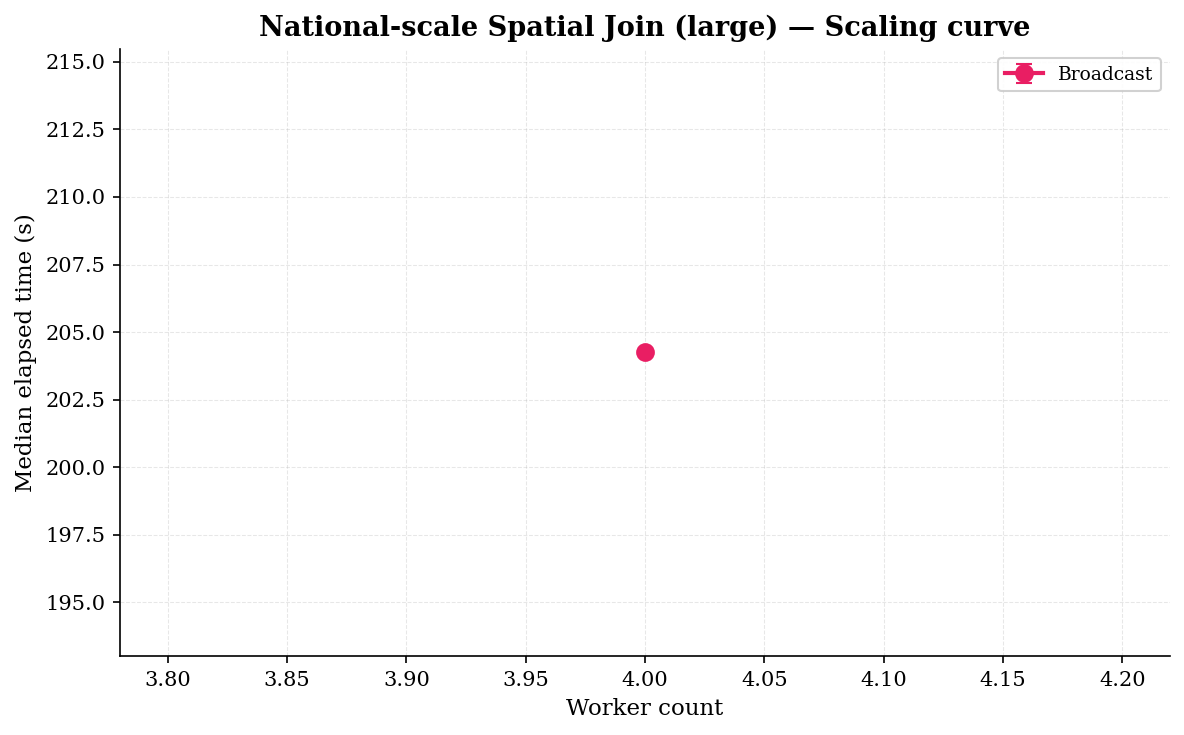

In [15]:
plot_scaling_curve(rq2_scaling, rq2_single_node, style, FIGURES_DIR)

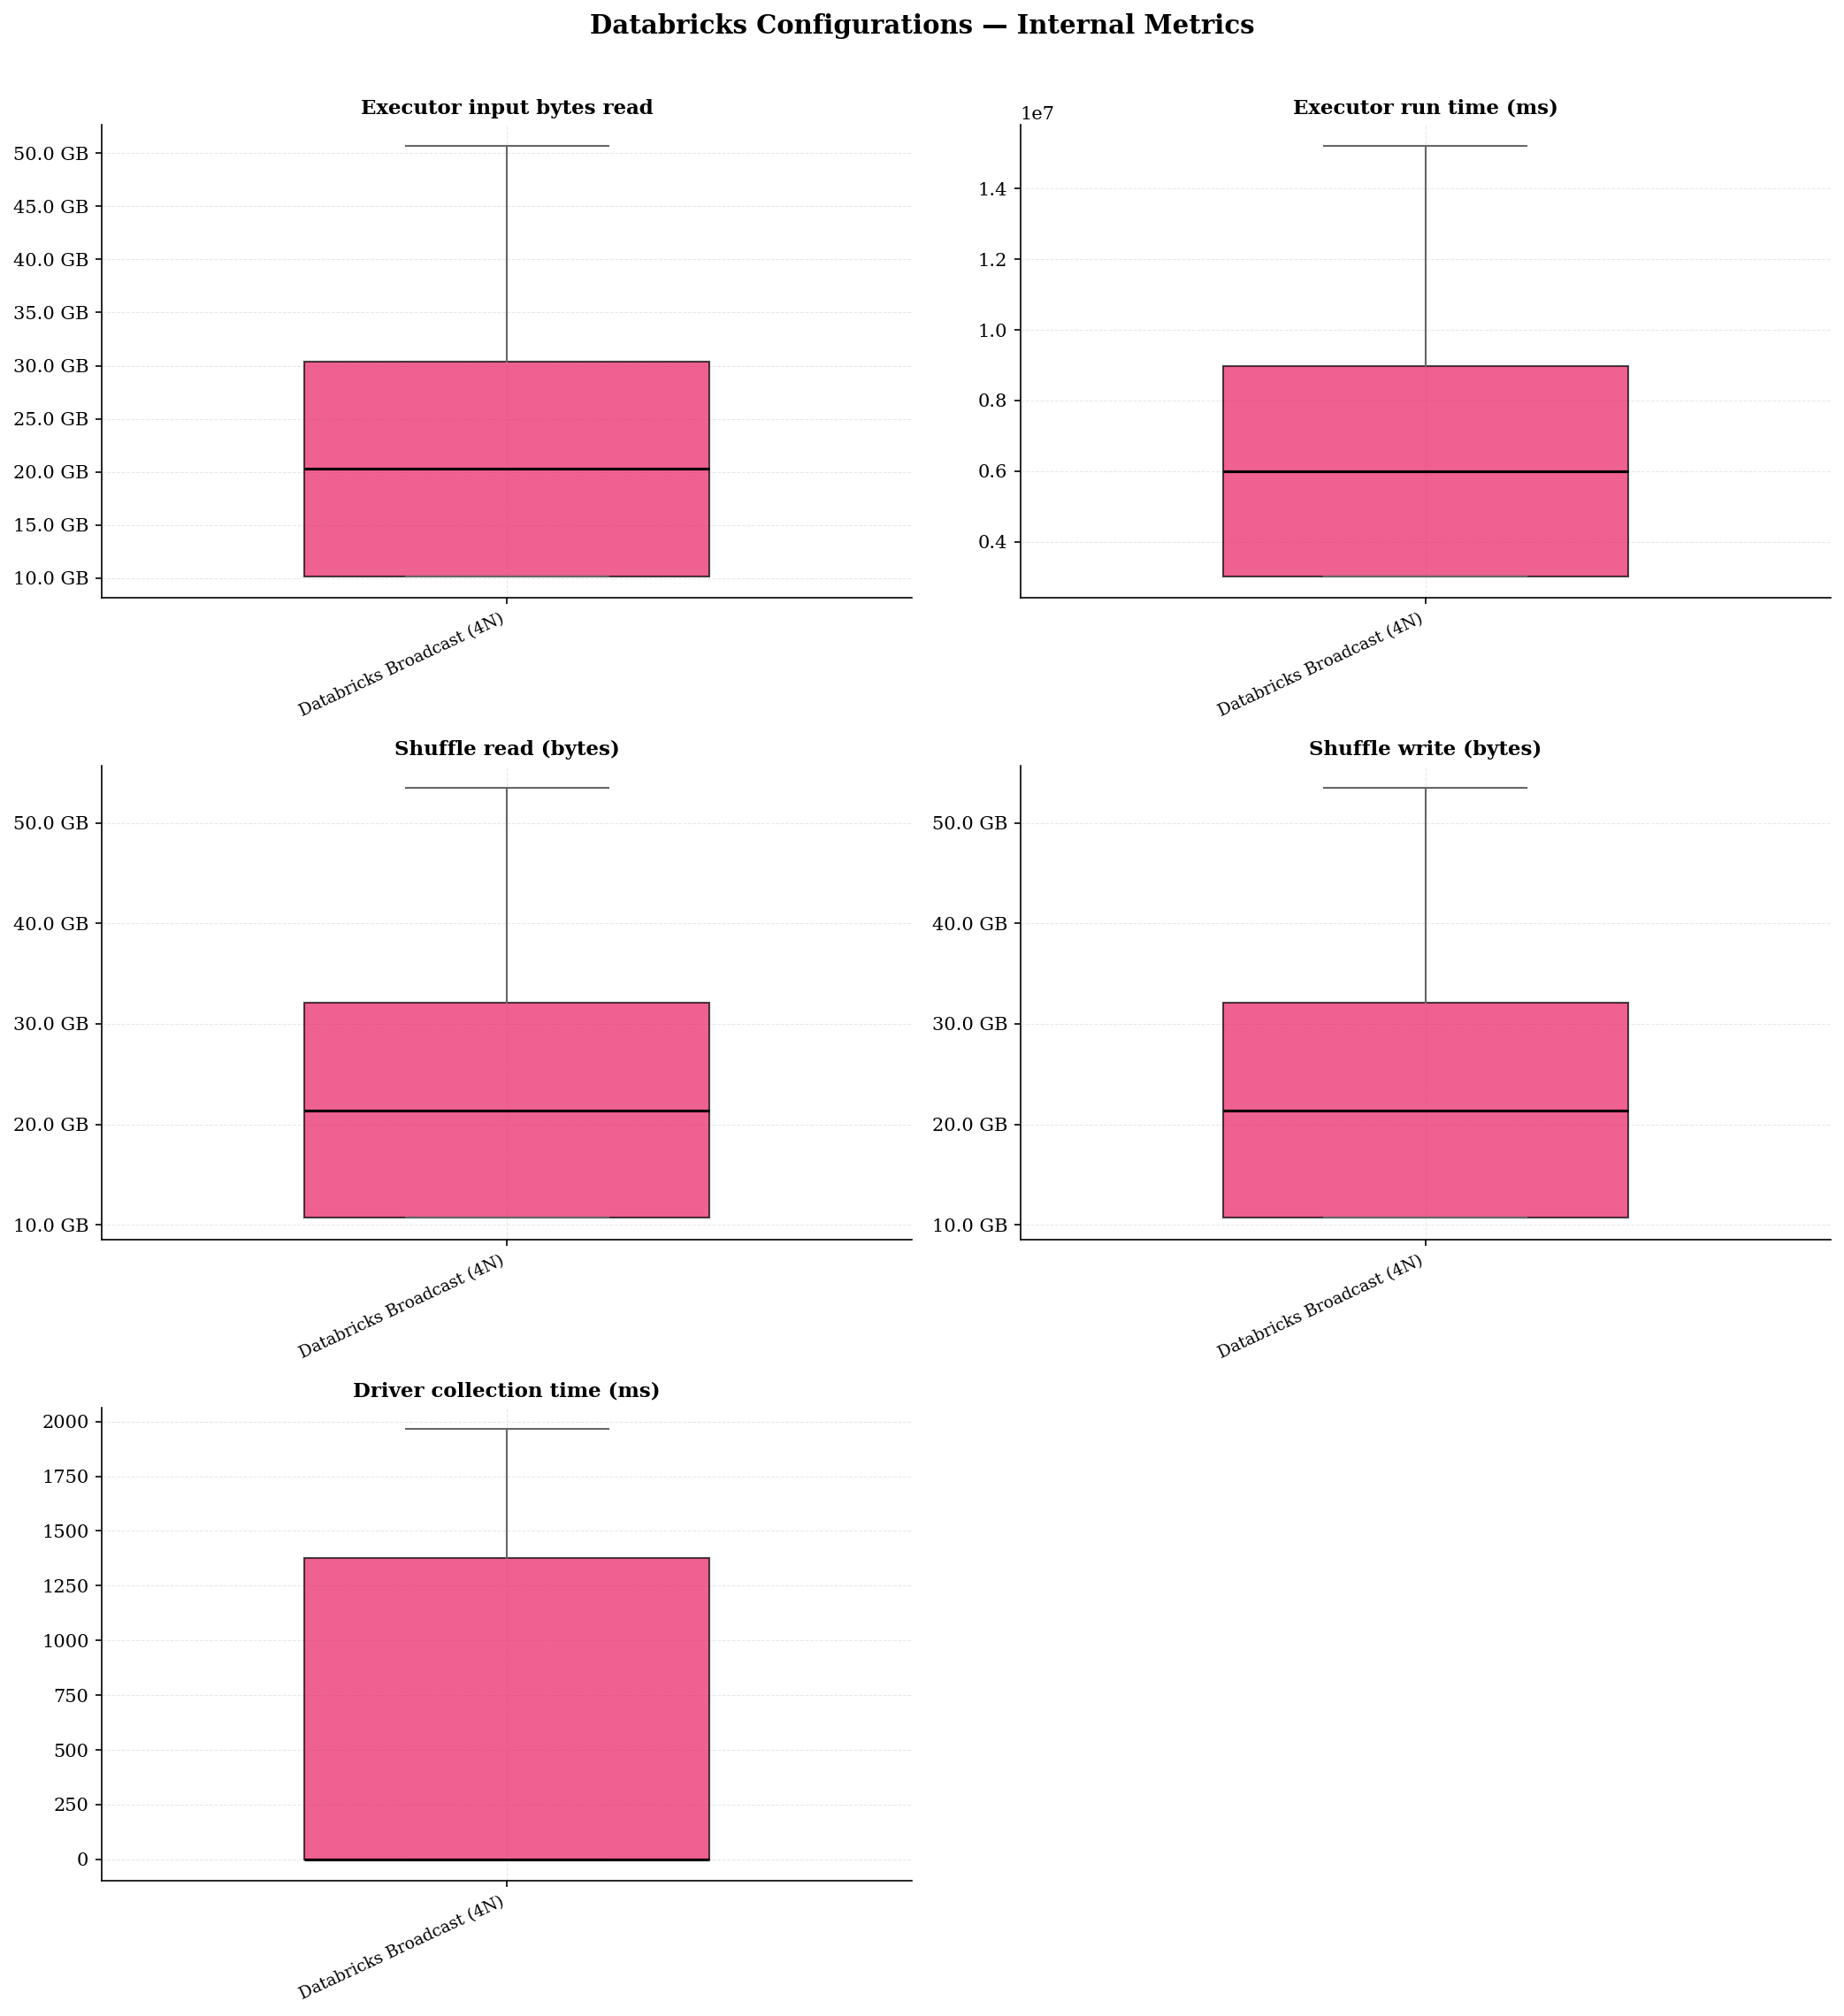

In [16]:
plot_databricks_metrics(successful, DATABRICKS_METRICS, style, FIGURES_DIR)

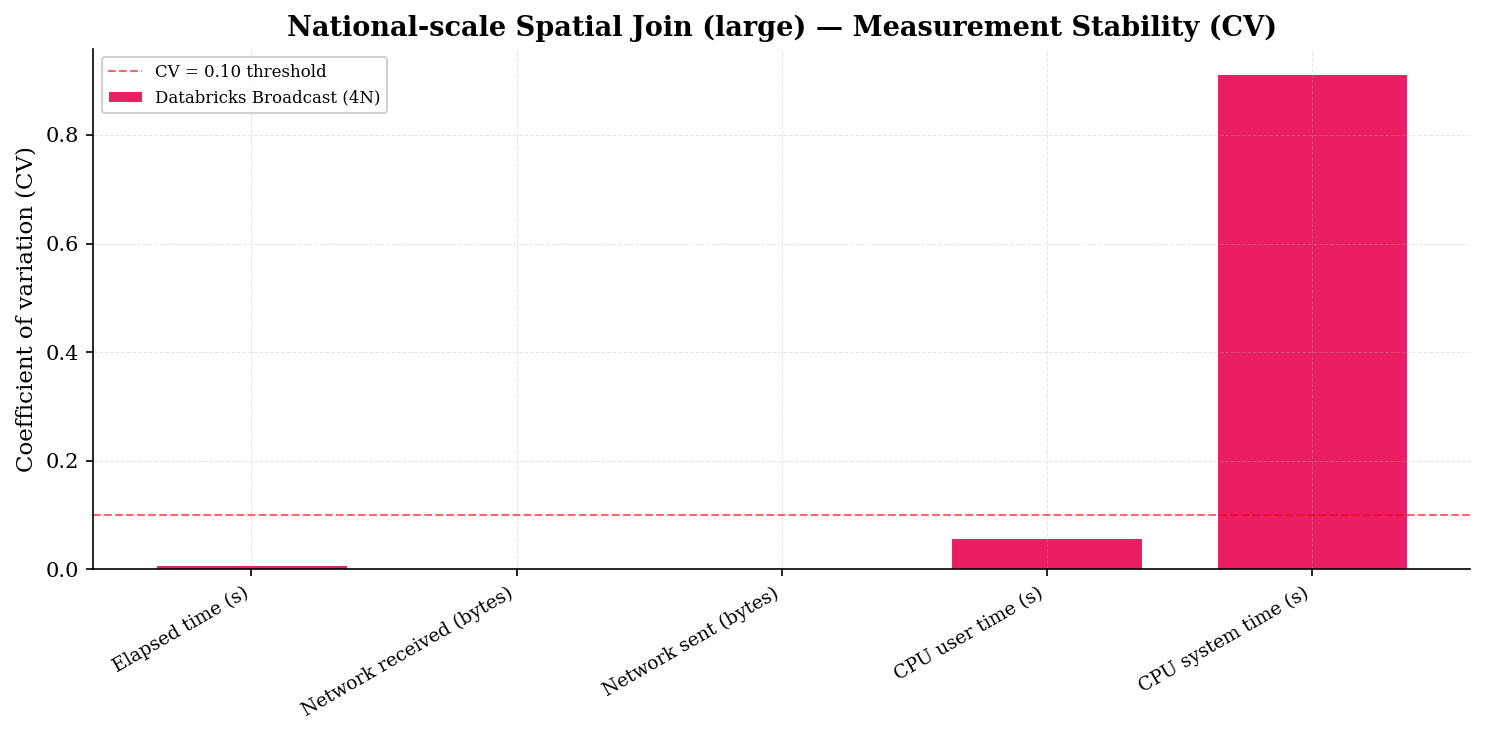

In [17]:
plot_cv_iqr(successful, PRIMARY_METRICS, AUXILIARY_METRICS, style, FIGURES_DIR)

## Cross-dataset-size Comparison

In [18]:
plot_size_scaling(successful, style, FIGURES_DIR)

table5 = build_scaling_table(successful, style.size_order)
if len(table5) > 0:
    print("Scaling factors:")
    display(table5)

In [19]:
plot_ranking_stability(successful, table3, style)

## LaTeX Export

In [20]:
compact_t1 = compact_descriptive_table(table1)
compact_t1.to_latex(TABLES_DIR / "rq2_table1_descriptive_stats.tex", escape=False)

table1.to_latex(TABLES_DIR / "rq2_table1_descriptive_stats_full.tex", escape=True, float_format="%.4f")

table2.to_latex(TABLES_DIR / "rq2_table2_cross_pass.tex", escape=True, float_format="%.4f")

if len(table3) > 0:
    split_pairwise_effects(table3).to_latex(
        TABLES_DIR / "rq2_table3a_effect_sizes.tex", escape=False, float_format="%.4f"
    )
    split_pairwise_significance(table3).to_latex(
        TABLES_DIR / "rq2_table3b_significance.tex", escape=False, float_format="%.4f"
    )

if len(table4) > 0:
    format_consistency_table(table4).to_latex(
        TABLES_DIR / "rq2_table4_consistency.tex", escape=True, index=False
    )

if len(table5) > 0:
    table5.to_latex(TABLES_DIR / "rq2_table5_size_scaling.tex", escape=True, float_format="%.4f")

print(f"LaTeX tables exported to {TABLES_DIR}/")
for f in sorted(TABLES_DIR.glob("*.tex")):
    print(f"  {f.name}")

LaTeX tables exported to tables/
  rq1_ranking.tex
  rq2_table1_descriptive_stats.tex
  rq2_table1_descriptive_stats_full.tex
  rq2_table2_cross_pass.tex
  table1_descriptive_stats.tex
  table2_cross_pass.tex
  table3_pairwise.tex
  table4_consistency.tex
